In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

In [2]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "shopping_list_agent"

LANGSMITH_API_KEY:  ········


In [3]:
_set_env("GOOGLE_API_KEY")

GOOGLE_API_KEY:  ········


In [26]:
from typing import TypedDict, Literal

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'shopping_list', 'instructions']

### States ####

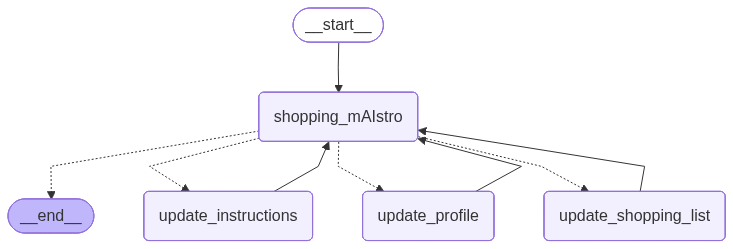

In [27]:
import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
from typing import Optional
from pydantic import BaseModel, Field, model_validator

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",temperature=0)


#Preferred Item
class PreferredItem(BaseModel):
    """Remembered product preference - maps a casual name to a specific product."""
    generic_name: str = Field(description="Short name the user uses, e.g. 'milk'")
    product_name: str = Field(description="Full product name, e.g. 'Pauls Full Cream Milk 2L'")


# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    store_preference: Optional[str] = Field(description="The user's preferred shopping store", default=None)
    dietary_choice: Optional[str] = Field(description="the user's dietary requirements", default="No specific dietary requirements")
    preferred_items: list[PreferredItem] = Field(
        default_factory=list,
        description="Known product preferences — populated over time from conversation"
    )
    # number_of_paxs:Optional[int] = Field(description="the number of persons in user's family", default=2)

    @model_validator(mode="before")
    @classmethod
    def coerce_preferred_items(cls, values):
        import json as _json
        pi = values.get("preferred_items")
        if isinstance(pi, str):
            try:
                values["preferred_items"] = _json.loads(pi)
            except Exception:
                values["preferred_items"] = []
        return values

# Shopping list schema
class ShoppingItem(BaseModel):
    """A single item on the active shopping list, populated from MCP search results."""
    item_name:  str = Field(description="Full product name returned by MCP, e.g. 'Pauls Full Cream Milk 2L'")
    # store: Literal["Woolworths", "Coles", "Aldi"] = Field(
    #     default="Aldi",
    #     description="Store this item is available at, from MCP result 'store' field"
    # )
    quantity:   str = Field(default="1", description="How many the user wants")
    # unit_price: Optional[str] = Field(default=None, description="Price string from MCP, e.g. '$2.50'")
    # on_special: Optional[bool] = Field(default=None, description="True if isDiscounted from MCP result")
    status: Literal["to buy", "purchased", "removed"] = Field(default="to buy")

# Create the Trustcall extractor for updating the user profile 
profile_extractor = create_extractor(
    model,
    tools=[Profile],
    tool_choice="Profile",
)

# Chatbot instruction for choosing what to update and what tools to call 
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. 

You are designed to be a shopping companion to a user, helping them keep track of their shopping list for Australian Supermarkets.

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them) 
2. The user's shopping list
3. General instructions for updating the shopping list

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current Shopping List (may be empty if no tasks have been added yet):
<shopping_list>
{shopping_list}
</shopping_list>

Here are the current user-specified preferences for updating the shopping list (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below. 

2. Decide whether any of the your long-term memory should be updated:
- If personal information was provided about the user, update the user's profile by calling UpdateMemory tool with type `user`
- If shopping items are mentioned, update the shopping list by calling UpdateMemory tool with type `shopping_list`
- If the user has specified preferences for how to update the shopping list, update the instructions by calling UpdateMemory tool with type `instructions`

3. Tell the user that you have updated your memory, if appropriate:
- Do not tell the user you have updated the user's profile
- Tell the user them when you update the shopping list
- Do not tell the user that you have updated instructions

4. Err on the side of updating the shopping list. No need to ask for explicit permission.

5. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made.

6. When the user asks for his shopping list show his shopping list for different stores"""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

# Instructions for updating the Shopping list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update Shopping list items. 

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""

# Node definitions
def shopping_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve profile memory from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    # Retrieve task memory from the store
    namespace = ("shopping_list", user_id)
    memories = store.search(namespace)
    shopping_list = "\n".join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = ""
    
    system_msg = MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile, shopping_list=shopping_list, instructions=instructions)

    # Respond using memory as well as the chat history
    response = model.bind_tools([UpdateMemory]).invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": [response]}

def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("profile", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Profile"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Invoke the extractor
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

def update_shopping_list(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("shopping_list", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "ShoppingItem"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Create the Trustcall extractor for updating the shopping list
    shopping_extractor = create_extractor(
        model,
        tools=[ShoppingItem],
        tool_choice=tool_name,
        enable_inserts=True
    )

    # Invoke the extractor
    result = shopping_extractor.invoke({"messages": updated_messages,
                                        "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )

    # Respond to the tool call made in shopping_mAIstro, confirming the update
    tool_calls = state['messages'][-1].tool_calls
    updated_items = [r.model_dump(mode="json") for r in result["responses"]]
    update_msg = f"Updated shopping list: {updated_items}"
    return {"messages": [{"role": "tool", "content": update_msg, "tool_call_id": tool_calls[0]['id']}]}

def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]
    
    namespace = ("instructions", user_id)

    existing_memory = store.get(namespace, "user_instructions")
        
    # Format the memory in the system prompt
    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store 
    key = "user_instructions"
    store.put(namespace, key, {"memory": new_memory.content})
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}

# Conditional edge
def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> Literal[END, "update_shopping_list", "update_instructions", "update_profile"]:

    """Reflect on the memories and chat history to decide whether to update the memory collection."""
    message = state['messages'][-1]
    if len(message.tool_calls) ==0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['args']['update_type'] == "user":
            return "update_profile"
        elif tool_call['args']['update_type'] == "shopping_list":
            return "update_shopping_list"
        elif tool_call['args']['update_type'] == "instructions":
            return "update_instructions"
        else:
            raise ValueError

# Create the graph + all nodes
builder = StateGraph(MessagesState)

# Define the flow of the memory extraction process
builder.add_node(shopping_mAIstro)
builder.add_node(update_shopping_list)
builder.add_node(update_profile)
builder.add_node(update_instructions)
builder.add_edge(START, "shopping_mAIstro")
builder.add_conditional_edges("shopping_mAIstro", route_message)
builder.add_edge("update_shopping_list", "shopping_mAIstro")
builder.add_edge("update_profile", "shopping_mAIstro")
builder.add_edge("update_instructions", "shopping_mAIstro")

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# We compile the graph with the checkpointer and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [28]:
config = {"configurable": {"thread_id": "2", "user_id": "Lance"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="My name is Soundhar. I live in SYD. I want to buy milk, chips and toilet gel")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

My name is Soundhar. I live in SYD. I want to buy milk, chips and toilet gel


Key '$defs' is not supported in schema, ignoring


================================== Ai Message ==================================

[]
Tool Calls:
  UpdateMemory (3ac4286d-7b33-490a-8ea8-ae2fdba0971a)
 Call ID: 3ac4286d-7b33-490a-8ea8-ae2fdba0971a
  Args:
    update_type: user
  UpdateMemory (4b7555f9-30f2-4b49-96e0-3c34cb37e520)
 Call ID: 4b7555f9-30f2-4b49-96e0-3c34cb37e520
  Args:
    update_type: shopping_list
================================= Tool Message =================================

updated profile
================================== Ai Message ==================================

[]
Tool Calls:
  UpdateMemory (41f5ef88-6c66-44ad-ae55-b404a04010f3)
 Call ID: 41f5ef88-6c66-44ad-ae55-b404a04010f3
  Args:
    update_type: shopping_list
================================= Tool Message =================================

Updated shopping list: [{'item_name': 'milk', 'quantity': '1', 'status': 'to buy'}, {'item_name': 'chips', 'quantity': '1', 'status': 'to buy'}, {'item_name': 'toilet gel', 'quantity': '1', 'status': 'to buy'}]
====

In [29]:
# User input for a ToDo
input_messages = [HumanMessage(content="I also want to get chicken breast and Spanish onions.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I also want to get chicken breast and Spanish onions.
================================== Ai Message ==================================

[]
Tool Calls:
  UpdateMemory (d0d9b78d-85ae-447d-879b-9c0253ef8054)
 Call ID: d0d9b78d-85ae-447d-879b-9c0253ef8054
  Args:
    update_type: shopping_list
================================= Tool Message =================================

Updated shopping list: [{'item_name': 'chicken breast', 'quantity': '1', 'status': 'to buy'}, {'item_name': 'Spanish onions', 'quantity': '1', 'status': 'to buy'}]
================================== Ai Message ==================================

[{'type': 'text', 'text': "I've added chicken breast and Spanish onions to your shopping list. Is there anything else you'd like to add?", 'extras': {'signature': 'EjQKMgEMOdbH4wOY4AQjtW1ie8aRLuKBlGY/IaVCcvHmViEZARJe9+ZeHYcqZGrDjrTr2KqV'}}]


In [30]:
input_messages = [HumanMessage(content="Now give me the shopping list.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Now give me the shopping list.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here is your current shopping list:\n\n*   Milk (1)\n*   Chips (1)\n*   Toilet gel (1)\n*   Chicken breast (1)\n*   Spanish onions (1)\n\nSince you are in Sydney, you can find these items at major supermarkets like Coles or Woolworths. Would you like me to help you organize this list by aisle or store?', 'extras': {'signature': 'EjQKMgEMOdbH3Uk7U+oMMle0teggXDwNvX/sm6dUMtpMt3fzDcOS3vG2Mot9xLHiBTYZrhDD'}}]


In [31]:
# User input to update instructions for creating ToDos
input_messages = [HumanMessage(content="I don't want chicken , now give the updated list")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I don't want chicken , now give the updated list
================================== Ai Message ==================================

[]
Tool Calls:
  UpdateMemory (b89a2f82-4763-4ba2-b8ce-855e93b5fe37)
 Call ID: b89a2f82-4763-4ba2-b8ce-855e93b5fe37
  Args:
    update_type: shopping_list
================================= Tool Message =================================

Updated shopping list: [{'item_name': 'chicken breast', 'quantity': '1', 'status': 'removed'}]
================================== Ai Message ==================================

[{'type': 'text', 'text': "I've updated your shopping list by removing the chicken breast. Here is your current list:\n\n*   Milk (1)\n*   Chips (1)\n*   Toilet gel (1)\n*   Spanish onions (1)\n\nYou can find these items at your local Coles or Woolworths. Let me know if you need anything else!", 'extras': {'signature': 'EjQKMgEMOdbHUvTBvFu7QLVZ5KZActZ2xwk8QNguW/K78NBmtHV